In [9]:
import torch
from bevfusion.bevfusion import BEVFusion

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BEVFusion().to(device)
model.eval()
model.load_state_dict(torch.load("checkpoints/bevfusion_pytorch.pth", map_location=device))

<All keys matched successfully>

In [11]:
DEMO_IDX = 100 # Available demo index: [0, 100, 200, 300, 400]
load_path = f"data/nuscenes_demo_{DEMO_IDX}.pt"
demo_data = torch.load(load_path, map_location='cpu')

imgs = demo_data['imgs'].to(device)
points_mm = demo_data['points_mm'].to(device)
mats_dict_mm = {k: v.to(device) for k, v in demo_data['mats_dict_mm'].items()}

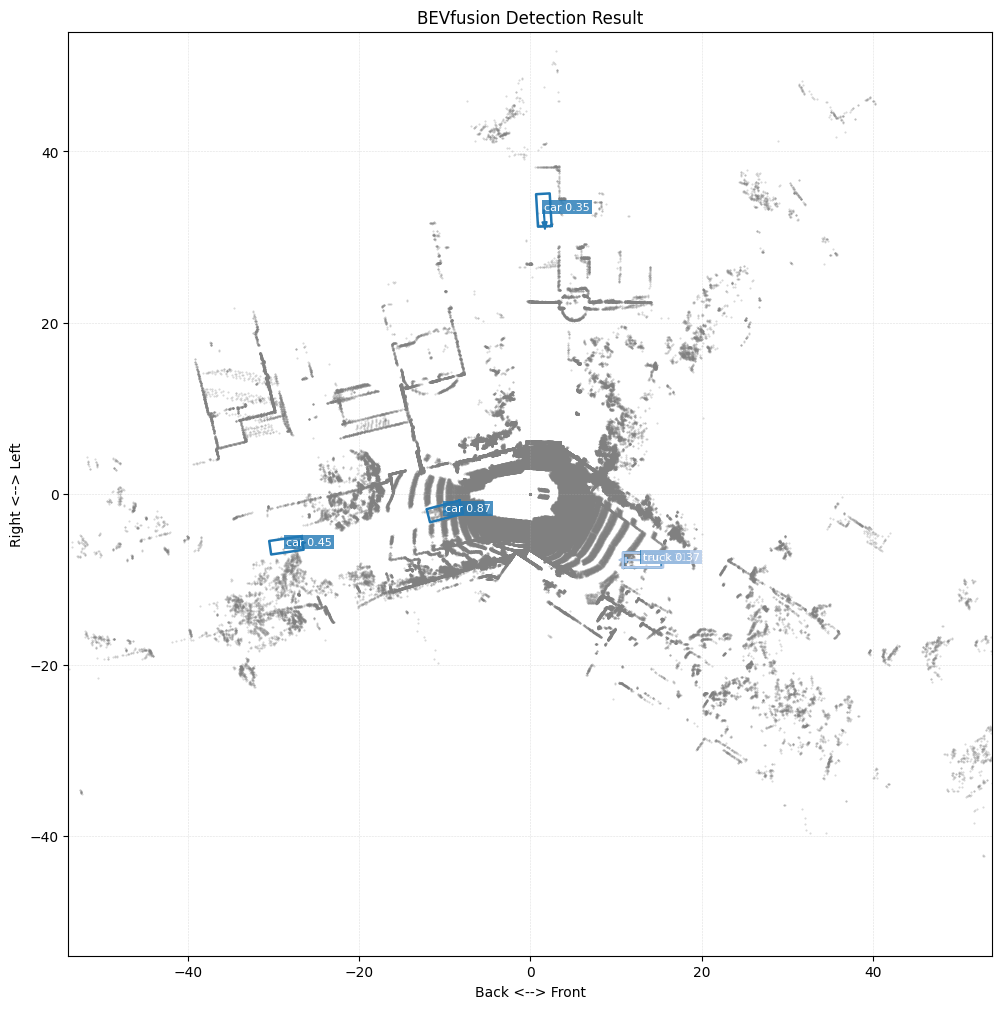

In [12]:
dict_results = model(imgs, points_mm, mats_dict_mm)
decoded_boxes_from_model = model.decode_bbox(dict_results['bbox_preds'], score_threshold=0.2)
model.visualize_results(
    points_mm[0, :, :3].cpu().numpy(),
    decoded_boxes_from_model,
    score_thr=0.3,
    point_size=0.2,
    point_alpha=0.35,
    point_color='gray'
)